<a href="https://colab.research.google.com/github/Istinger/IA-Talleres-Practicas/blob/main/Proa%C3%B1o_Practica1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 1 — Preprocesamiento de datos

**Realizado por:** Jossue Proaño
**Fecha:** 28 de abril de 2026  
**Carrera:** Ingeniería en Ciencias de la Computación  
**Asignatura:** Inteligencia Artificial


In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import matplotlib.pyplot as plt
print(" Todas las librerías cargadas correctamente")

 Todas las librerías cargadas correctamente


##FASE 1. Anatomía de un Dataset
Dataset de estudiantes. Ejecuta el siguiente bloque. No lo modifiques nada todavía, solo léelo con
atención

In [2]:
import numpy as np
import pandas as pd
datos = {
 "nombre": ["Ana", "Luis", "María", "Carlos", "Sofía", "Diego"],
 "edad": [21, 23, 20, 25, 22, 21],
 "promedio_gpa": [8.9, 7.4, 9.5, 6.1, 8.2, 7.8],
 "horas_estudio": [18, 10, 22, 6, 15, 12],
 "distancia_km": [2.5, 15.0, 0.8, 40.2, 5.1, 8.7],
 "carrera": [
 "Computación","Computación","Redes","Redes","Computación","Redes"],
 "nivel_ingles": [
 "Básico", "Intermedio","Avanzado","Básico","Avanzado","Intermedio"],
 "beca": [1, 0, 1, 0, 1, 0],
 "aprobado": ["Sí", "No", "Sí", "No", "Sí", "No"]
}
df = pd.DataFrame(datos)
print(df)
print(f"\nDimensiones del dataset: {df.shape}")
print(df)
print(f"\nDimensiones del dataset: {df.shape}")



   nombre  edad  promedio_gpa  horas_estudio  distancia_km      carrera  \
0     Ana    21           8.9             18           2.5  Computación   
1    Luis    23           7.4             10          15.0  Computación   
2   María    20           9.5             22           0.8        Redes   
3  Carlos    25           6.1              6          40.2        Redes   
4   Sofía    22           8.2             15           5.1  Computación   
5   Diego    21           7.8             12           8.7        Redes   

  nivel_ingles  beca aprobado  
0       Básico     1       Sí  
1   Intermedio     0       No  
2     Avanzado     1       Sí  
3       Básico     0       No  
4     Avanzado     1       Sí  
5   Intermedio     0       No  

Dimensiones del dataset: (6, 9)
   nombre  edad  promedio_gpa  horas_estudio  distancia_km      carrera  \
0     Ana    21           8.9             18           2.5  Computación   
1    Luis    23           7.4             10          15.0  Computa

#Actividad 1.1: Identifica la estructura
##P1:¿Cuántas instancias (filas) tiene este dataset? ¿Qué representa cada instancia en el mundo real?

Instancias == 6(0-5)

Una instancia representa un unico elemento del mundo real y esta compuesta por un conjunto de variables o atributos en este caso las columnas que describen sus caracteristicas

##P2:Lista todos los atributos (columnas). Ahora sepáralos en dos grupos: ¿cuáles actuarían como features y cuál sería el label si tu objetivo fuera predecir si un estudiante aprueba o no?

nombre, edad, promedio_gpa, horas_estudio, distancia_km, carrera, nivel_ingles, beca, aprobado


Grupo1(feature) vs Grupo2(label/resultado):
###(feature)
nombre(cualitativa),   
edad(cuantitativa),
horas_estudio(cuantitativa)
carrera(cualtitativa)               
nivel_ingles(cualitativa),                 
promedio_gpa(cuantitativa),
distancia_km(cuantitativa)

###(label/resultado)
beca y aprobado(de los cuales se pueden obtener mediante promedio_gpa, horas_estudio )


###P3. La columna nombre es un atributo, pero ¿debería ser un feature para un modelo de ML? ¿Por qué sí o por qué no?
No, es un atributo en este caso nos es irrelevante ya que no obtenemos nada, a menos que queramos realizar un analisis sobre la cantidad de hombres y mujeres, en este caso se crearia un nuevo atributo




###Actividad 1.2: Clasifica las variables. Completa la siguiente tabla en tu notebook. Para cada columna,indica su tipo según los criterios estudiados en clase:


In [3]:
clasificacion = {
 "columna": ["edad", "promedio_gpa", "horas_estudio", "distancia_km",
 "carrera", "nivel_ingles", "beca", "aprobado"],
 "cuantitativa_o_cualitativa": ["?", "?", "?", "?", "?", "?", "?", "?"],
 "discreta_o_continua": ["?", "?", "?", "?", "?", "?", "?", "?"],
 "nominal_u_ordinal": ["NA","NA","NA","NA","?", "?", "?", "?"]
}
df_tipos = pd.DataFrame(clasificacion)
print(df_tipos)


         columna cuantitativa_o_cualitativa discreta_o_continua  \
0           edad                          ?                   ?   
1   promedio_gpa                          ?                   ?   
2  horas_estudio                          ?                   ?   
3   distancia_km                          ?                   ?   
4        carrera                          ?                   ?   
5   nivel_ingles                          ?                   ?   
6           beca                          ?                   ?   
7       aprobado                          ?                   ?   

  nominal_u_ordinal  
0                NA  
1                NA  
2                NA  
3                NA  
4                 ?  
5                 ?  
6                 ?  
7                 ?  


###P4: nivel_ingles tiene los valores Básico, Intermedio y Avanzado. ¿Es nominal u ordinal? ¿En qué te basas para decidirlo? ¿Importa esa distinción a la hora de entrenar un modelo?

Es ordinal ya que clasifica segun el orden jerarquico o categorias(Basico,Intermedio,Avanzado) , lo que mantienen una relacion de orden preestablecida entre sus categorias.Si por otra parte es importante ya que nos sirve para realizar modelos de regresion logistica ordinal (logit orderneado)

###P5. La columna beca solo contiene 0 y 1. ¿Es cuantitativa discreta o cualitativa nominal? Justifica tu respuesta. Pista: piensa en si tiene sentido calcular la media de esos valores.
Es nominal ya que se puede identificar clases, como 0 reprobado/sin beca y 1 aprobado/con beca

###Actividad 1.3: Inspeccionando tipos de datos

In [4]:
print("Tipos de datos detectados por pandas:")
print(df.dtypes)
print("\nEstadísticas descriptivas (solo numéricas):")
print(df.describe())


Tipos de datos detectados por pandas:
nombre            object
edad               int64
promedio_gpa     float64
horas_estudio      int64
distancia_km     float64
carrera           object
nivel_ingles      object
beca               int64
aprobado          object
dtype: object

Estadísticas descriptivas (solo numéricas):
            edad  promedio_gpa  horas_estudio  distancia_km      beca
count   6.000000      6.000000       6.000000       6.00000  6.000000
mean   22.000000      7.983333      13.833333      12.05000  0.500000
std     1.788854      1.192337       5.741661      14.68615  0.547723
min    20.000000      6.100000       6.000000       0.80000  0.000000
25%    21.000000      7.500000      10.500000       3.15000  0.000000
50%    21.500000      8.000000      13.500000       6.90000  0.500000
75%    22.750000      8.725000      17.250000      13.42500  1.000000
max    25.000000      9.500000      22.000000      40.20000  1.000000


###P6. ¿Coinciden los tipos que detecta pandas (int64, object, float64) con tu clasificación teórica de la actividad 1.2? Señala al menos un caso donde no coincidan y explica por qué pandas puede estar "equivocado" desde la perspectiva conceptual.

Beca no coincide ya que debe ser una variable cualtitativa nominal y al realizarse operaciones donde el resultado sera de tipo flotante, beca al ser (int64) lo realiza por eso tambien estaria erroneo

###P7. Observa las estadísticas descriptivas. ¿Qué columna tiene mayor dispersión (std)? ¿Qué problema podría ocasionar esa diferencia de escala si alimentas este dataset directamente a un algoritmo como KNN?

*   La columna con mayor disperscion lo tiene distancia 14.68615 con respecto a la media
*   Podria dañar el resultado del modelo ya que los resultados estar entre 1 - 14 toma el valor como un outlier al ser poco significativo afecta mi dataset y pierde la capacidad de distinguir datos normales


#FASE 2. Escalado con NumPy
##Actividad 2.1: Preparando los datos

In [5]:
# Extraemos SOLO las columnas numéricas continuas para esta fase
columnas_numericas = ["promedio_gpa", "horas_estudio", "distancia_km"]
X = df[columnas_numericas].values.astype(float)
print("Matriz de datos original:")
print(X)
print(f"\nForma: {X.shape} → {X.shape[0]} instancias, {X.shape[1]} features")


Matriz de datos original:
[[ 8.9 18.   2.5]
 [ 7.4 10.  15. ]
 [ 9.5 22.   0.8]
 [ 6.1  6.  40.2]
 [ 8.2 15.   5.1]
 [ 7.8 12.   8.7]]

Forma: (6, 3) → 6 instancias, 3 features


###P8. ¿Por qué excluimos edad y beca de esta matriz aunque también son numéricas? ¿Tiene sentido escalar la columna beca que solo contiene 0 y 1

Estariamos realizando KKD una normalizacion de datos , es decir no siempre es mejor mientras mas datos mejor el modelo por lo que realizaremos una bondad de ajuste donde podemos ver de mejor manera si nuestro modelo esta bien creando asi bajando el umbral de error y se perderia la coherencia al añadir datos irrelevantes en este caso

##Actividad 2.2: Normalización Min-Max

In [6]:
def min_max_manual(X):
 """
 Normalización Min-Max: transforma cada columna al rango [0, 1]
 Fórmula: x' = (x - min) / (max - min)
 """
 X_min = X.min(axis=0) # mínimo por columna
 X_max = X.max(axis=0) # máximo por columna
 X_norm = (X - X_min) / (X_max - X_min)
 return X_norm, X_min, X_max
X_minmax, mins, maxs = min_max_manual(X)
print("=== RESULTADO MIN-MAX ===")
print(f"{'Feature':<18} {'Min original':>14} {'Max original':>14}")
print("-" * 48)
for i, col in enumerate(columnas_numericas):
 print(f"{col:<18} {mins[i]:>14.2f} {maxs[i]:>14.2f}")
print("\nDatos normalizados (Min-Max):")
df_minmax = pd.DataFrame(X_minmax, columns=[c+"_mm" for c in columnas_numericas])
print(df_minmax.round(4))


=== RESULTADO MIN-MAX ===
Feature              Min original   Max original
------------------------------------------------
promedio_gpa                 6.10           9.50
horas_estudio                6.00          22.00
distancia_km                 0.80          40.20

Datos normalizados (Min-Max):
   promedio_gpa_mm  horas_estudio_mm  distancia_km_mm
0           0.8235            0.7500           0.0431
1           0.3824            0.2500           0.3604
2           1.0000            1.0000           0.0000
3           0.0000            0.0000           1.0000
4           0.6176            0.5625           0.1091
5           0.5000            0.3750           0.2005


###P9. Después de aplicar Min-Max, ¿cuál es el valor mínimo y máximo que puede tomar cualquier columna? Verifica que tus resultados lo confirmen. ¿Qué representa un valor transformado de 0.0? ¿Y uno de 1.0?

1.   (min) 0.0
2.   (max) 1.0



*   (min) 0.0 --> el punto de partida , el valor minimo
*   (max) 1.0 -> el punto de llegada , el valor maximo

Lo que garantiza la estabilidad en el proceso de optimizacion promoviendo una convergencia mas rapida durante mitiga los problemas relacionados con la desaparicion o explision de gradientes permitiendo que los modelos sean mas faciles de interpretar cuando las caracteristicas de un conjunto de datos estan en la misma escala lo que permite identificar, comparar y visualizar las relaciones






###P10. Fíjate en la columna distancia_km. Carlos vive a 40.2 km, que es un valor extremo. Ahora imagina que llega un nuevo estudiante que vive a 80 km. Si agregas ese dato y vuelves a normalizar, ¿qué le pasará al valor transformado de todos los demás estudiantes? ¿Es eso un problema? ¿Por qué?

Ocurre un problema de outlier(valor atipico) donde nuestro data set puede tomar interpretaciones erroneas eso quiere decir que nuestro data set que teniamos antes va a comprimirse hacia abajo ,tomando como relevante el valor mayor en este caso 40.2, la distribucion no se mantiene igual y cambia su forma ya que depende del nuevo extremo


###Actividad 2.3: Estandarización Z-Score


In [7]:
def zscore_manual(X):
 """
 Z-Score: transforma cada columna a media=0 y desv.est.=1
 Fórmula: z = (x - media) / desviacion_estandar
 """
 media = X.mean(axis=0)
 std = X.std(axis=0) # desviación estándar de la población
 X_z = (X - media) / std
 return X_z, media, std
X_zscore, medias, stds = zscore_manual(X)
print("=== RESULTADO Z-SCORE ===")
print(f"{'Feature':<18} {'Media':>10} {'Desv.Est.':>12}")
print("-" * 42)
for i, col in enumerate(columnas_numericas):
 print(f"{col:<18} {medias[i]:>10.3f} {stds[i]:>12.3f}")
print("\nDatos estandarizados (Z-Score):")
df_z = pd.DataFrame(X_zscore, columns=[c+"_z" for c in columnas_numericas])
print(df_z.round(4))

=== RESULTADO Z-SCORE ===
Feature                 Media    Desv.Est.
------------------------------------------
promedio_gpa            7.983        1.088
horas_estudio          13.833        5.241
distancia_km           12.050       13.407

Datos estandarizados (Z-Score):
   promedio_gpa_z  horas_estudio_z  distancia_km_z
0          0.8422           0.7950         -0.7123
1         -0.5359          -0.7314          0.2200
2          1.3934           1.5581         -0.8391
3         -1.7303          -1.4945          2.0997
4          0.1991           0.2226         -0.5184
5         -0.1684          -0.3498         -0.2499


###P11. Después de aplicar Z-Score, ¿cuál es el valor mínimo y máximo que puede tomar cualquier columna? Verifica que tus resultados lo confirmen. ¿Qué representa un valor transformado de 0.0? ¿Y uno de 1.0?
1.   (min) media es 0
2.   (max) desviacion tipica de 1

###P12. Carlos tiene horas_estudio = 6. Después del Z-Score, su valor transformado es negativo.¿Qué significa eso en términos estadísticos? ¿Significa que Carlos estudia "mal"? ¿Qué dice ese valor sobre su posición relativa al grupo?

Quiere decir que carlos tiene un valor que esta por debajo de la media, es decir que esta por debajo del promedio del grupo  

###P13. Compara los valores de Carlos y Sofía para distancia_km después de Min-Max y después de Z-Score. ¿Cuál de las dos transformaciones te parece más informativa sobre la "rareza" de vivir a 40 km? Argumenta.

Tabla de valores (Min-Max y Z-Score):

| Persona | Min-Max (distancia_km_mm) | Z-Score (distancia_km_z) |
| --- | ---: | ---: |
| Carlos (índice 3) | 1.0000 | 2.0997 |
| Sofía (índice 4) | 0.1091 | -0.5184 |


Me parece mas informativa el los datos estandarizados por Z-Score donde la posicion Carlos(3) esta mas lejos de la media y Sofia(4) se encuentra por debajo de la media en terminos de distancia puedo ver que Carlos con distancia de 2 vive super lejos de la escuela y sofia de -0.5 esta un poco mas cerca de la media que vive mas cerca de la escuela

###Actividad 2.4: Comparación visual de las tres columnas

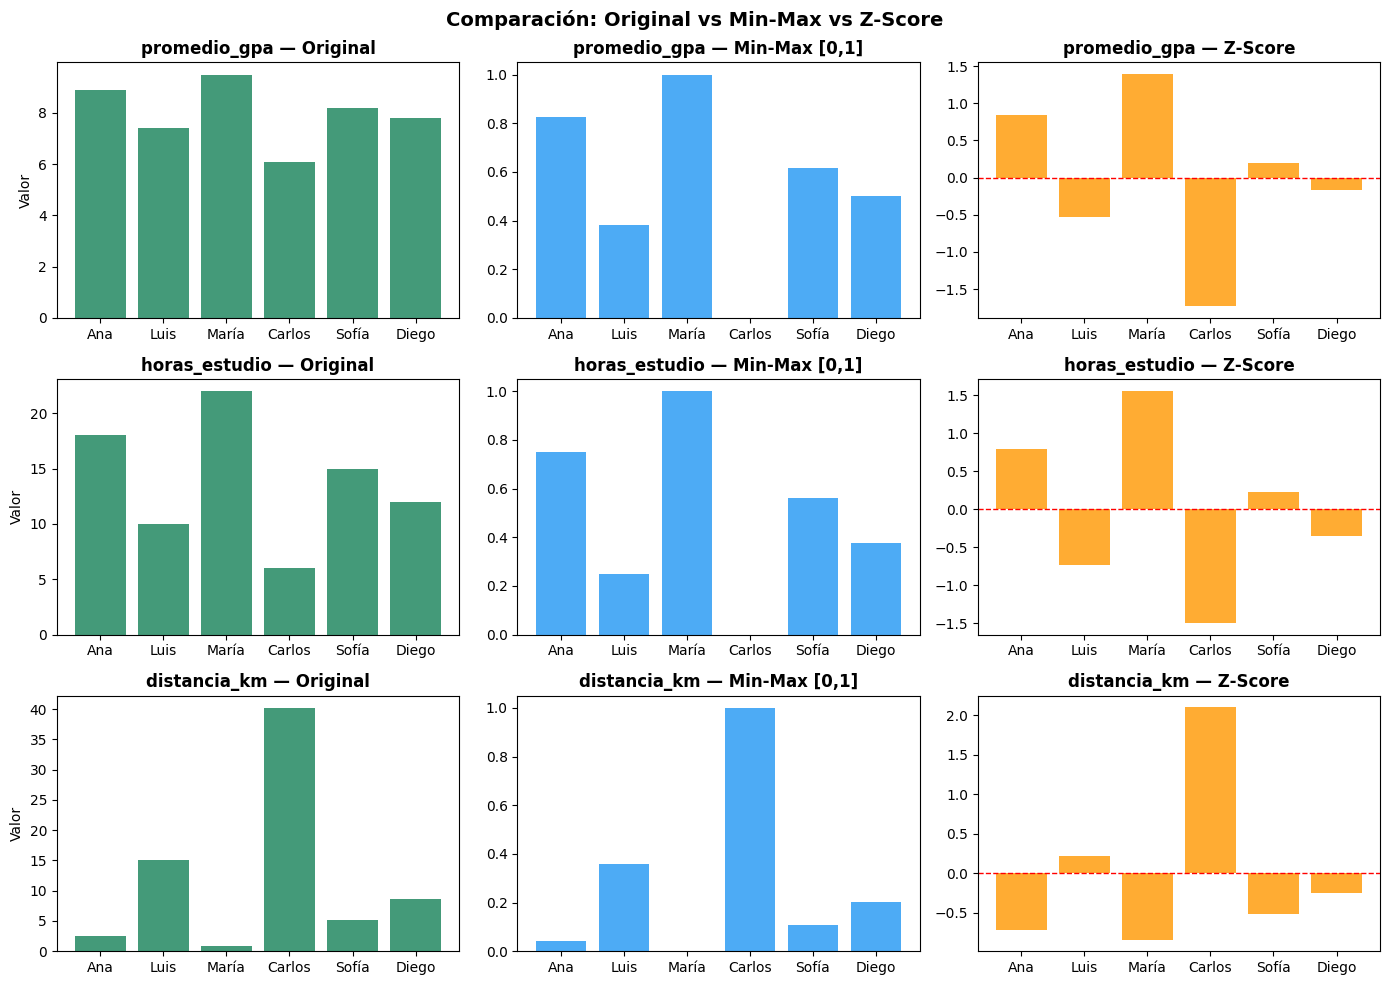

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
nombres = df["nombre"].values
for i, col in enumerate(columnas_numericas):
 # Original
 axes[i, 0].bar(nombres, X[:, i], color="#158158", alpha=0.8)
 axes[i, 0].set_title(f"{col} — Original", fontweight='bold')
 axes[i, 0].set_ylabel("Valor")
 # Min-Max
 axes[i, 1].bar(nombres, X_minmax[:, i], color="#2196F3", alpha=0.8)
 axes[i, 1].set_title(f"{col} — Min-Max [0,1]", fontweight='bold')
 # Z-Score
 axes[i, 2].bar(nombres, X_zscore[:, i], color="#FF9800", alpha=0.8)
 axes[i, 2].axhline(0, color='red', linestyle='--', linewidth=1)
 axes[i, 2].set_title(f"{col} — Z-Score", fontweight='bold')
plt.suptitle("Comparación: Original vs Min-Max vs Z-Score", fontsize=14,
fontweight='bold')
plt.tight_layout()
plt.savefig("comparacion_escalado.png", dpi=100)
plt.show()

##P14. Observa la gráfica de distancia_km. Las proporciones relativas entre estudiantes, ¿se mantienen igual en las tres versiones? ¿Qué es lo que realmente cambia entre Original, Min-Max y Z-Score?


*   Original -->Las proporciones para diferentes graficas varian entre 0 a 40 en caso del eje Y en caso es dificil comparar features
*   Min-Max --> El objetivo de la normalizacion es que cada punto trabaje en la misma es cala, asi cada feature es igual de importante
*   Z-Score -->Al usar esta normalizacion el rango se acoto de -2 a 2 en el eje y lo cual es mejor comparado a tener valores como 40 donde no se pueden visualzacr bien los datos




##Actividad 2.5: Simulando un outlier extremo

In [9]:
# Añadimos un estudiante con una distancia extrema
X_con_outlier = np.vstack([X, [8.5, 14, 120.0]]) # 120 km
# Aplicamos Min-Max sobre los datos CON outlier
X_mm_con_outlier, _, _ = min_max_manual(X_con_outlier)
# Aplicamos Z-Score sobre los datos CON outlier
X_z_con_outlier, _, _ = zscore_manual(X_con_outlier)
print("=== Columna distancia_km con outlier (120 km) ===")
print(f"\n{'Estudiante':<10} {'Original':>10} {'Min-Max':>10} {'Z-Score':>10}")
print("-" * 44)
nombres_ext = list(nombres) + ["Nuevo"]
for j in range(len(nombres_ext)):
  print(f"{nombres_ext[j]:<10} {X_con_outlier[j,2]:>10.1f} "
      f"{X_mm_con_outlier[j,2]:>10.4f} {X_z_con_outlier[j,2]:>10.4f}")

=== Columna distancia_km con outlier (120 km) ===

Estudiante   Original    Min-Max    Z-Score
--------------------------------------------
Ana               2.5     0.0143    -0.6280
Luis             15.0     0.1191    -0.3137
María             0.8     0.0000    -0.6708
Carlos           40.2     0.3305     0.3201
Sofía             5.1     0.0361    -0.5626
Diego             8.7     0.0663    -0.4721
Nuevo           120.0     1.0000     2.3271


##P15. Observa lo que ocurre con los valores de los otros estudiantes en Min-Max después de agregar el outlier de 120 km. ¿Qué problema genera esto? ¿Por qué Z-Score es más robusto ante este caso? ¿Existe alguna técnica mejor aún?

1. Los datos se comprimieron con el min- max en un solo punto desde Ana hasta Diego y no se puede tomarlos como datos validos ya que el rango es de [0,1]

2. Al usar el Z score con un outlier mejora el rendimiento y precision del modelo al tener un rango desde [-2,2] por lo que se puede mejorar la distancia entre los puntos y se pueden interpetar mejor los resultados, si existe una tecnica mejor llamada Robust Scaler aplicando un escalado a los features de forma para que sea mas robusto ante los outliers



#FASE 3. Dataset real con Pandas: Palmer Penguins

In [10]:
import pandas as pd
# Cargamos el dataset directamente desde Hugging Face
url = "https://huggingface.co/datasets/SIH/palmer-penguins/resolve/main/penguins.csv"
df_penguins = pd.read_csv(url)
print("=== PRIMERA VISTA DEL DATASET ===")
print(df_penguins.head(8))
print(f"\nDimensiones: {df_penguins.shape}")
print(f"\nColumnas: {list(df_penguins.columns)}")

=== PRIMERA VISTA DEL DATASET ===
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   
6  Adelie  Torgersen            38.9           17.8              181.0   
7  Adelie  Torgersen            39.2           19.6              195.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  
5       3650.0    male  2007  
6       3625.0  female  2007  
7       4675.0    male  2007  

Dimensiones: (344, 

##Actividad 3.1: Exploración inicial obligatoria

In [11]:
print("\n=== TIPOS DE DATOS ===")
print(df_penguins.dtypes)
print("\n=== VALORES NULOS ===")
print(df_penguins.isnull().sum())
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df_penguins.describe())
print("\n=== VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS ===")
for col in df_penguins.select_dtypes(include='object').columns:
  print(f"{col}: {df_penguins[col].unique()}")


=== TIPOS DE DATOS ===
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
year                   int64
dtype: object

=== VALORES NULOS ===
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

=== ESTADÍSTICAS DESCRIPTIVAS ===
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      342.000000     342.000000         342.000000   342.000000   
mean        43.921930      17.151170         200.915205  4201.754386   
std          5.459584       1.974793          14.061714   801.954536   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.225000      15.600000         190.000000  3550.000000   
50%         44.450000      17.30000

##P16. Identifica para este dataset: ¿cuántas instancias tiene? ¿Cuáles son las features numéricas? ¿Cuál sería el label más lógico para una tarea de clasificación?


1. Instancias:344 en total, pero en el dataset se acorto por head y se tomo 8

2. Features numericas: 5 si se toma en cuenta el año
3. Label:species , sex






##P17. ¿Hay valores nulos? ¿En qué columnas? ¿Por qué es importante tratar los valores nulos antes de aplicar escalado? ¿Qué pasaría si escalas con NaN presentes?

Si, existen valores nulos en:

*   bill_length_mm        2
*   bill_depth_mm         2
*  flipper_length_mm     2
*   body_mass_g           2
*   sex                  11


Es importante tratarlos posteriormente ya que no se va a poder realizar operaciones con NaN, si se escala con valores nulos el modelo tendra errores porquen no sabe como procesar un valor vacio o puede que dominen las variables con rasgos grandes sobre las pequeñas, es decir se distorcionara por eso existe KDD donde la data se somete a un proceso de ETL

##Actividad 3.2: Clasificación de variables del dataset

##P18. Para cada columna de df_penguins, clasifica su tipo completo. Presta especial atención a sex e island. ¿Son las dos nominales? ¿Cambiaría la respuesta si ordenamos las islas por temperatura promedio del océano?


## Valores únicos en columnas categóricas

| Columna | Valores únicos |
| --- | --- |
| species | Adelie, Gentoo, Chinstrap |
| island | Torgersen, Biscoe, Dream |
| sex | male, female, NaN (missing) |




*   Si las dos se podrian ser llamadas nominales ya que se pueden distinguir sus clases o se pueden clasificar por el tipo
*   Si, cambiaria la respuesta ya que se estan ordenando estableciendo un orden en la temperatura sea [Alto,Medio,Bajo]



##Actividad 3.3: Preprocesamiento y escalado

In [12]:
# Paso 1: Eliminar filas con valores nulos
df_clean = df_penguins.dropna()
print(f"Filas originales: {len(df_penguins)} → Filas limpias: {len(df_clean)}")
# Paso 2: Seleccionar features numéricas
features_num = ["bill_length_mm", "bill_depth_mm",
"flipper_length_mm", "body_mass_g"]
X_penguins = df_clean[features_num].values
print("\nEstadísticas ANTES del escalado:")
print(pd.DataFrame(X_penguins, columns=features_num).describe().round(2))

Filas originales: 344 → Filas limpias: 333

Estadísticas ANTES del escalado:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          333.00         333.00             333.00       333.00
mean            43.99          17.16             200.97      4207.06
std              5.47           1.97              14.02       805.22
min             32.10          13.10             172.00      2700.00
25%             39.50          15.60             190.00      3550.00
50%             44.50          17.30             197.00      4050.00
75%             48.60          18.70             213.00      4775.00
max             59.60          21.50             231.00      6300.00


##19. Mira las escalas de body_mass_g (en gramos, ~3500–6000) vs bill_depth_mm (en mm, ~13–21). Si entrenas un modelo con estos datos sin escalar, ¿cuál variable tendrá más peso en el cálculo de distancia? ¿Es eso justo biológicamente?

Tomara mas en cuenta el valor mayor en este caso si existe una diferencia de peso de
300 g y el tamaño del pico en 3mm el modelo tomara mas relevancia el que tenga mayor valor o magnitud como relevancia en este caso 300g por ejemplo en el algoritmo de K-means o K nearest neighbor calcula que tan cerca esta un punto de otro, si no se escala la distancia se vera distorcionada por la variable de mayor rango

No es justo, ni correcto debido a que un cambio en el pico significa un cambio gigantezco por la teoria de evolucion de darwin que nos demuestra que existio una adaptacion gigantesca, mientras que el cambio de peso puede ser algo comun o no segun la alimentacion o area donde se tomaron los datos de la poblacion

##Actividad 3.4: Análisis de distribuciones

In [13]:
# Paso 3: Aplicar Min-Max
mm = MinMaxScaler()
X_mm = mm.fit_transform(X_penguins)
# Paso 4: Aplicar Z-Score
zs = StandardScaler()
X_zs = zs.fit_transform(X_penguins)
# Paso 5: Comparar estadísticas
print("\n--- Min-Max ---")
print(pd.DataFrame(X_mm, columns=features_num).describe().round(4))
print("\n--- Z-Score ---")
print(pd.DataFrame(X_zs, columns=features_num).describe().round(4))


--- Min-Max ---
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count        333.0000       333.0000           333.0000     333.0000
mean           0.4325         0.4839             0.4910       0.4186
std            0.1989         0.2344             0.2376       0.2237
min            0.0000         0.0000             0.0000       0.0000
25%            0.2691         0.2976             0.3051       0.2361
50%            0.4509         0.5000             0.4237       0.3750
75%            0.6000         0.6667             0.6949       0.5764
max            1.0000         1.0000             1.0000       1.0000

--- Z-Score ---
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count        333.0000       333.0000           333.0000     333.0000
mean          -0.0000        -0.0000             0.0000      -0.0000
std            1.0015         1.0015             1.0015       1.0015
min           -2.1780        -2.0673            -2.0699      -1.8744


###P20. ¿El escalado cambia la forma de la distribución (histograma) o solo la escala de los ejes? ¿Por qué importa esa respuesta cuando evaluamos normalidad de los datos?
No cambia la distribucion la forma sigue siendo la misma, cambiaria la escala del eje horizontal X(variables independientes) donde se puede visualizar de mejor manera la distribucion en caso de un min-max[0,-1] o Z-Score[-2,2], es importante cambiar la escala de los ejes para poder realizar un mejor interpretacion de los datos

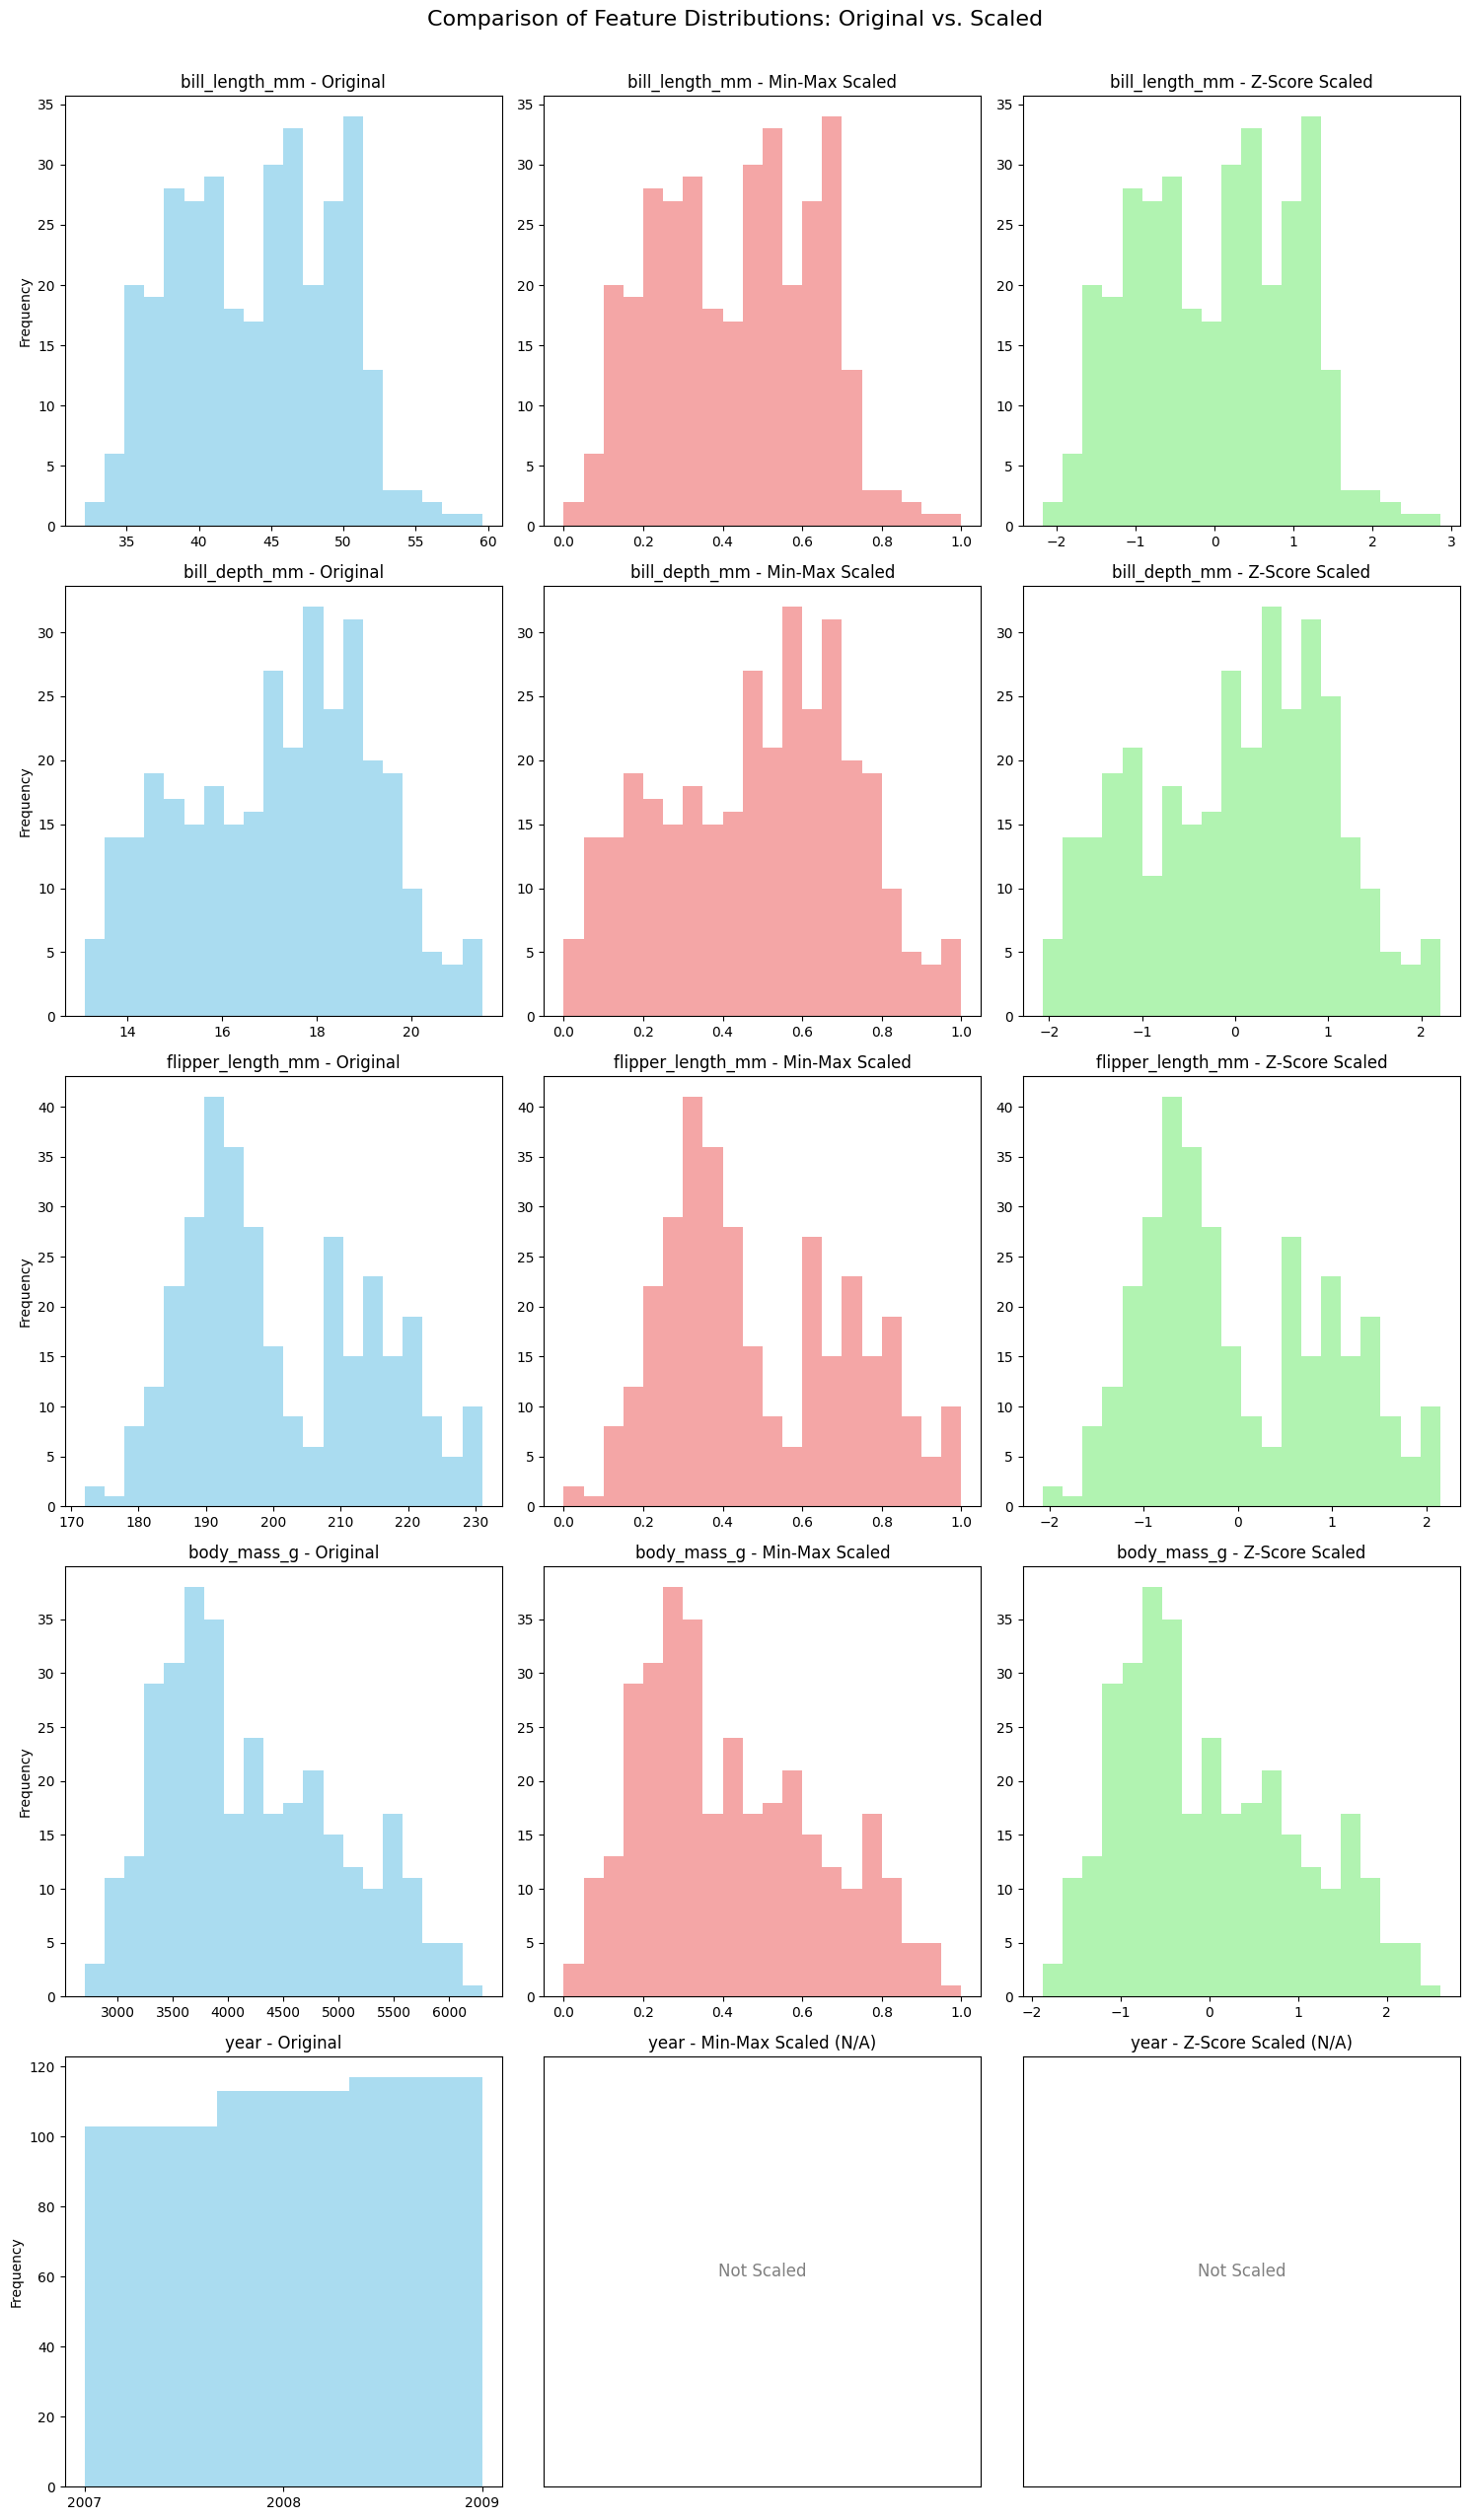

In [14]:
# The 'features_num' list from previous cells (jLB6tZ6m73AE and z-0uXZksHmtQ)
# contains the features that were scaled: bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g.
# We will use this list to correctly index X_mm and X_zs.
features_num_scaled = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

# Create a new list of all numerical features to visualize, including 'year'
features_to_visualize = list(features_num_scaled)
features_to_visualize.append("year")

fig, axes = plt.subplots(len(features_to_visualize), 3, figsize=(15, 5 * len(features_to_visualize)))

# Ensure axes is always 2D, even if there's only one feature to visualize
if len(features_to_visualize) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, col in enumerate(features_to_visualize):
    # Original Distribution (always plot this)
    # For 'year', use unique values as bins for clarity
    bins_val = df_clean[col].nunique() if col == "year" else 20
    axes[i, 0].hist(df_clean[col], bins=bins_val, color='skyblue', alpha=0.7)
    axes[i, 0].set_title(f'{col} - Original')
    axes[i, 0].set_ylabel('Frequency')
    if col == "year":
        axes[i, 0].set_xticks(df_clean[col].unique()) # Set specific ticks for year

    # Scaled Distributions (only for features that were actually scaled)
    if col in features_num_scaled:
        # Get the index of the current column within the list used for scaling
        original_idx = features_num_scaled.index(col)

        # Min-Max Scaled Distribution
        axes[i, 1].hist(X_mm[:, original_idx], bins=20, color='lightcoral', alpha=0.7)
        axes[i, 1].set_title(f'{col} - Min-Max Scaled')

        # Z-Score Scaled Distribution
        axes[i, 2].hist(X_zs[:, original_idx], bins=20, color='lightgreen', alpha=0.7)
        axes[i, 2].set_title(f'{col} - Z-Score Scaled')
    else:
        # For 'year' or any other non-scaled numerical feature, indicate it's not applicable
        axes[i, 1].set_title(f'{col} - Min-Max Scaled (N/A)')
        axes[i, 1].text(0.5, 0.5, 'Not Scaled', horizontalalignment='center', verticalalignment='center', transform=axes[i, 1].transAxes, fontsize=12, color='gray')
        axes[i, 1].set_xticks([]) # Remove ticks for empty plots
        axes[i, 1].set_yticks([])

        axes[i, 2].set_title(f'{col} - Z-Score Scaled (N/A)')
        axes[i, 2].text(0.5, 0.5, 'Not Scaled', horizontalalignment='center', verticalalignment='center', transform=axes[i, 2].transAxes, fontsize=12, color='gray')
        axes[i, 2].set_xticks([]) # Remove ticks for empty plots
        axes[i, 2].set_yticks([])

plt.tight_layout()
plt.suptitle('Comparison of Feature Distributions: Original vs. Scaled', y=1.02, fontsize=16)
plt.show()

###P21. Observa la distribución de body_mass_g. ¿Se parece a una campana de Gauss (distribución normal) o tiene alguna asimetría? ¿Afecta eso a la elección entre Min-Max y Z-Score?

Existe una asimetria en body_mass_g casi llega a formarse una campana de gauss, si afecta en la eleccion al minimizar datos outliers para obtener mejor precision en el modelo. Una observacion que hay que tomar en cuenta es que para usar min-max por lo general se usan en imagenes, redes neuronales especificas, mientras que el Z-Score se usa en modelso de regresion, K-Means, PCA, aunque en este caso tamien se podria usar un Robust-Scaler ya que veo el pico y este es favorable a datos con fallos o ruidosos

#FASE 4: HuggingFace + sklearn

###Actividad 4.1: Retornando al dataset limpio

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
url = "https://huggingface.co/datasets/SIH/palmer-penguins/resolve/main/penguins.csv"
df_penguins = pd.read_csv(url)
df_clean = df_penguins.dropna()
features_num = ["bill_length_mm", "bill_depth_mm",
"flipper_length_mm", "body_mass_g"]
X = df_clean[features_num].values
print(f"Dataset listo: {X.shape[0]} instancias, {X.shape[1]} features")
print(f"\nEstadísticas originales:")
print(pd.DataFrame(X, columns=features_num).describe().round(2))

Dataset listo: 333 instancias, 4 features

Estadísticas originales:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          333.00         333.00             333.00       333.00
mean            43.99          17.16             200.97      4207.06
std              5.47           1.97              14.02       805.22
min             32.10          13.10             172.00      2700.00
25%             39.50          15.60             190.00      3550.00
50%             44.50          17.30             197.00      4050.00
75%             48.60          18.70             213.00      4775.00
max             59.60          21.50             231.00      6300.00


In [16]:
# 1. Obtener valores máximos y mínimos de cada columna del arreglo X
max_vals = X.max(axis=0)
min_vals = X.min(axis=0)

# 2. Calcular el rango (Max - Min)
rangos = max_vals - min_vals

# 3. Crear un diccionario o DataFrame para visualizarlo con los nombres
df_rangos = pd.DataFrame({
    'Feature': features_num,
    'Min': min_vals,
    'Max': max_vals,
    'Rango': rangos
}).sort_values(by='Rango', ascending=False) # Ordenados de mayor a menor

print("--- RANGOS ORIGINALES (Ordenados) ---")
print(df_rangos.to_string(index=False))

--- RANGOS ORIGINALES (Ordenados) ---
          Feature    Min    Max  Rango
      body_mass_g 2700.0 6300.0 3600.0
flipper_length_mm  172.0  231.0   59.0
   bill_length_mm   32.1   59.6   27.5
    bill_depth_mm   13.1   21.5    8.4


###P22. Antes de continuar: ¿cuál de las cuatro features tiene mayor rango (max − min)? ¿Cuál tiene menor rango? Calcula ambos valores con código y anótalos, los vas a necesitar para comparar después.



*   CÁLCULO DE RANGOS(Min-Max)
Todas las features tienen un rango de 0 (min) y 1(max)

*   CÁLCULO DE RANGOS(Originales)

| Feature | Min | Max | Rango |
| --- | ---: | ---: | ---: |
| body_mass_g | 2700.0 | 6300.0 | 3600.0 |
| flipper_length_mm | 172.0 | 231.0 | 59.0 |
| bill_length_mm | 32.1 | 59.6 | 27.5 |
| bill_depth_mm | 13.1 | 21.5 | 8.4 |








###Actividad 4.2: División train/test. Antes de escalar, el dataset debe dividirse. Este orden no es opcional.

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(
X,
test_size=0.2, # 80% entrenamiento, 20% prueba
random_state=42 # fija la aleatoriedad para reproducibilidad
)
print(f"Train: {X_train.shape} → {X_train.shape[0]} pingüinos")
print(f"Test: {X_test.shape} → {X_test.shape[0]} pingüinos")

Train: (266, 4) → 266 pingüinos
Test: (67, 4) → 67 pingüinos


###P23. ¿Por qué se divide el dataset antes de aplicar el escalado y no después? Piensa en qué información usaría el scaler si lo aplicaras primero sobre todo el dataset. ¿Qué datos del test estarías "filtrando" al proceso de entrenamiento? Esto se llama data leakage; explícalo con tus propias palabras.

Ya que el data set de training tiene un 60% del data set debe ser escalado ya que este se va a tomar como el material para el aprendizaje del modelo, el 20% para un set de validacion para evaular y mejorar el rendimiento del modelo, donde actua como puntos de guardado para mejorar el modelo mientras que la parte restante el 20% donde la data que no ah sido tocada se convierte para el set de test el que va a ser usado para evaluar el rendimiendo del modelo simulando un entorno como el mundo real.

Supongamos que si aplico la normalizacion sobre todo el data set para entrenar a mi modelo, mi modelo va a rendir perfecto en el set de test pero se su habilidad para generalizar nueva informacion antes vista va a reducirse ya que le quite la capacidad para visualizar nuevos datos del mundo real, eso se dio a que la capacidad del test-set se inflo, es decir el modelo resulto en una evaluaciones super optimista porque el set-test se uso en el paso de preprocesamiento lo que solo se aplica al set-training, y causo una contaminacion de train-test

###Actividad 4.3: Aplicando los tres escaladores El patrón de uso es siempre el mismo:

In [18]:
# Instanciar los tres escaladores
mm_scaler = MinMaxScaler()
zs_scaler = StandardScaler()
rb_scaler = RobustScaler()
# Aplicar a train: fit + transform
X_train_mm = mm_scaler.fit_transform(X_train)
X_train_zs = zs_scaler.fit_transform(X_train)
X_train_rb = rb_scaler.fit_transform(X_train)
# Aplicar a test: solo transform (NO fit)
X_test_mm = mm_scaler.transform(X_test)
X_test_zs = zs_scaler.transform(X_test)
X_test_rb = rb_scaler.transform(X_test)
print("Parámetros aprendidos por MinMaxScaler (sobre train):")
print(f" Mínimos: {mm_scaler.data_min_.round(2)}")
print(f" Máximos: {mm_scaler.data_max_.round(2)}")
print("\nParámetros aprendidos por StandardScaler (sobre train):")
print(f" Medias: {zs_scaler.mean_.round(2)}")
print(f" Std: {zs_scaler.scale_.round(2)}")
print("\nParámetros aprendidos por RobustScaler (sobre train):")
print(f" Medianas: {rb_scaler.center_.round(2)}")
print(f" IQR: {rb_scaler.scale_.round(2)}")

Parámetros aprendidos por MinMaxScaler (sobre train):
 Mínimos: [  32.1   13.1  172.  2700. ]
 Máximos: [  59.6   21.5  231.  6050. ]

Parámetros aprendidos por StandardScaler (sobre train):
 Medias: [  44.08   17.07  201.41 4232.61]
 Std: [  5.41   1.97  14.24 809.57]

Parámetros aprendidos por RobustScaler (sobre train):
 Medianas: [  44.9   17.2  197.  4100. ]
 IQR: [   8.9    3.2   24.  1200. ]


###P22. Compara los parámetros que aprendió MinMaxScaler (mínimos y máximos) con los que calculaste manualmente en la Fase 2 con NumPy. ¿Son exactamente iguales o hay alguna diferencia pequeña? ¿A qué se debe si la hay?

En mi data set original por parte del body_mass_g tiene 6300 en (min-max original), mientras que el (min-max Scaler) existe un cambio de 6050, existe la diferencia de 250 ya que como estamos tomando un train-set no tiene todos los valores maximos ya que parte de la data se fue al test-set, asi el modelo estaria listo para aprender del test-set y obtener un umbral bajo de error

###P23. El RobustScaler aprende la mediana y el IQR de cada columna, no la media ni el std. Calcula manualmente la mediana y el IQR de body_mass_g en el train con NumPy y verifica que coincidan con rb_scaler.center_[3] y rb_scaler.scale_[3]

--- Verificación Manual (body_mass_g) ---
| Concepto | Manual | Scaler[3] |
| --- | ---: | ---: |
| Mediana / Center | 4100.0 | 4100.0 |
| IQR / Scale | 1200.0 | 1200.0 |


In [19]:
# Suponiendo que X_train es tu arreglo de entrenamiento y la columna 3 es body_mass_g
col_weight = X_train[:, 3]

# 1. Calcular Mediana (Center)
mediana_manual = np.median(col_weight)

# 2. Calcular IQR (Scale)
q75, q25 = np.percentile(col_weight, [75 ,25])
iqr_manual = q75 - q25

print(f"--- Verificación Manual (body_mass_g) ---")
print(f"Mediana Manual: {mediana_manual} | Scaler Center: {rb_scaler.center_[3]}")
print(f"IQR Manual:     {iqr_manual} | Scaler Scale:  {rb_scaler.scale_[3]}")

--- Verificación Manual (body_mass_g) ---
Mediana Manual: 4100.0 | Scaler Center: 4100.0
IQR Manual:     1200.0 | Scaler Scale:  1200.0



## Conclusión

Tener en cuenta que el escalado de datos debe realizarse con precaución para evitar data leakage. Además, el escalado es importante para que nuestro modelo de predicción sea acertado.

La separación de los conjuntos en training, validation y test debe hacerse de forma que la información no esté imparcial o sesgada, evitando data contamination, de modo que el modelo pueda adaptarse a entornos del mundo real. Una buena partición del set de test es clave para una evaluación robusta.

## Referencias

- [interactivechaos - RobustScaler]
	<https://interactivechaos.com/es/manual/tutorial-de-machine-learning/robustscaler>
- [Codecademy - Min-Max and Z-Score Normalization]
	<https://www.codecademy.com/article/min-max-zscore-normalization>
- [YouTube - Video de referencia]
	<https://www.youtube.com/watch?v=BkZga7XOR_s&t=47s>
- [4Geeks - Escalado de características]
	<https://4geeks.com/es/lesson/escalado-de-caracteristicas>
- [Codecademy - Training, Validation, Test Set]
	<https://www.codecademy.com/article/training-validation-test-set>
- [IBM - Data Leakage in Machine Learning]
	<https://www.ibm.com/think/topics/data-leakage-machine-learning>